# Artificial Non-Streaming Demo

This notebook mirrors the lean ZINC non-streaming demo, but uses an artificial NetworkX dataset generated in memory.

- source: cycle -> connector path -> star-ray graphs
- sample count: `DATASET_SIZE`
- fit mode: materialize generated graphs, then train normally
- outputs: 7 samples without feasibility filtering, then 7 with filtering


In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import random
import sys
from pathlib import Path

import numpy as np
from IPython.core.display import HTML

HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell; text-align: center; vertical-align: middle;}</style>')

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'conditional_node_field_graph_generator').is_dir():
        repo_root = candidate.resolve()
        break
else:
    raise RuntimeError(
        'Could not locate the NodeField repository from the current working directory. '
        'Start Jupyter from the repo root or the notebooks directory.'
    )

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from conditional_node_field_graph_generator.notebooks import configure_notebook
globals().update(configure_notebook(require_nsppk=True, print_torch=True))

from conditional_node_field_graph_generator.extensions.demo.pipeline import build_graph_generator
from conditional_node_field_graph_generator.extensions.demo.visualization import plot_networkx_graphs
from conditional_node_field_graph_generator.extensions.synthetic import generate_artificial_dataset


/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.2.0)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(


PyTorch version: 2.2.2
CUDA available: False


In [2]:
RANDOM_SEED = 7
DATASET_SIZE = 5000
CYCLE_LENGTH = 6
PATH_LENGTH = 4
NUM_RAYS = 3
RAY_LENGTH = 2
NODE_ALPHABET_SIZE = 3
EDGE_ALPHABET_SIZE = 1
NODE_ALPHABET_KIND = 'int'
EDGE_ALPHABET_KIND = 'int'
COMPONENT_SPECIFIC_ALPHABETS = True
FIT_BATCH_SIZE = 128
MAXIMUM_EPOCHS = 350
EMBEDDING_DIM = 64
MODEL_NAME = (
    f'artificial-cycle-path-star-n{DATASET_SIZE}'
    f'-c{CYCLE_LENGTH}-p{PATH_LENGTH}-r{NUM_RAYS}x{RAY_LENGTH}'
    f'-d{EMBEDDING_DIM}-b{FIT_BATCH_SIZE}-e{MAXIMUM_EPOCHS}'
)
DECODER_N_JOBS = -1

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

ARTIFICIAL_NODE_LABEL_COLORS = {
    0: '#fee2e2',
    1: '#fca5a5',
    2: '#dc2626',
    3: '#dbeafe',
    4: '#93c5fd',
    5: '#2563eb',
    6: '#dcfce7',
    7: '#86efac',
    8: '#16a34a',
}

ARTIFICIAL_GRAPH_PLOT_KWARGS = {
    'node_label_colors': ARTIFICIAL_NODE_LABEL_COLORS,
    'size': 4,
    'show_label': True,
    'cmap': 'tab20',
    'light': 0.4,
    'color_offset': 200,
    'node_size': 300,
    'node_linewidths': 2,
    'edge_width': 2,
}


Saved artificial dataset config: artificial-cycle-path-star-n5000-c6-p4-r3x2-na3.yaml
Loaded 5000 artificial graphs into memory for non-streaming fit.
Node count min/median/max = 16/16/16
Edge count min/median/max = 16/16/16
Metadata: {'cycle_length': 6, 'path_length': 4, 'num_rays': 3, 'ray_length': 2, 'node_alphabet_size': 3, 'edge_alphabet_size': 1, 'component_specific_alphabets': True, 'node_alphabets_by_component': {'cycle': [0, 1, 2], 'path': [3, 4, 5], 'star': [6, 7, 8]}, 'edge_alphabets_by_component': {'cycle': [0], 'path': [1], 'star': [2]}}


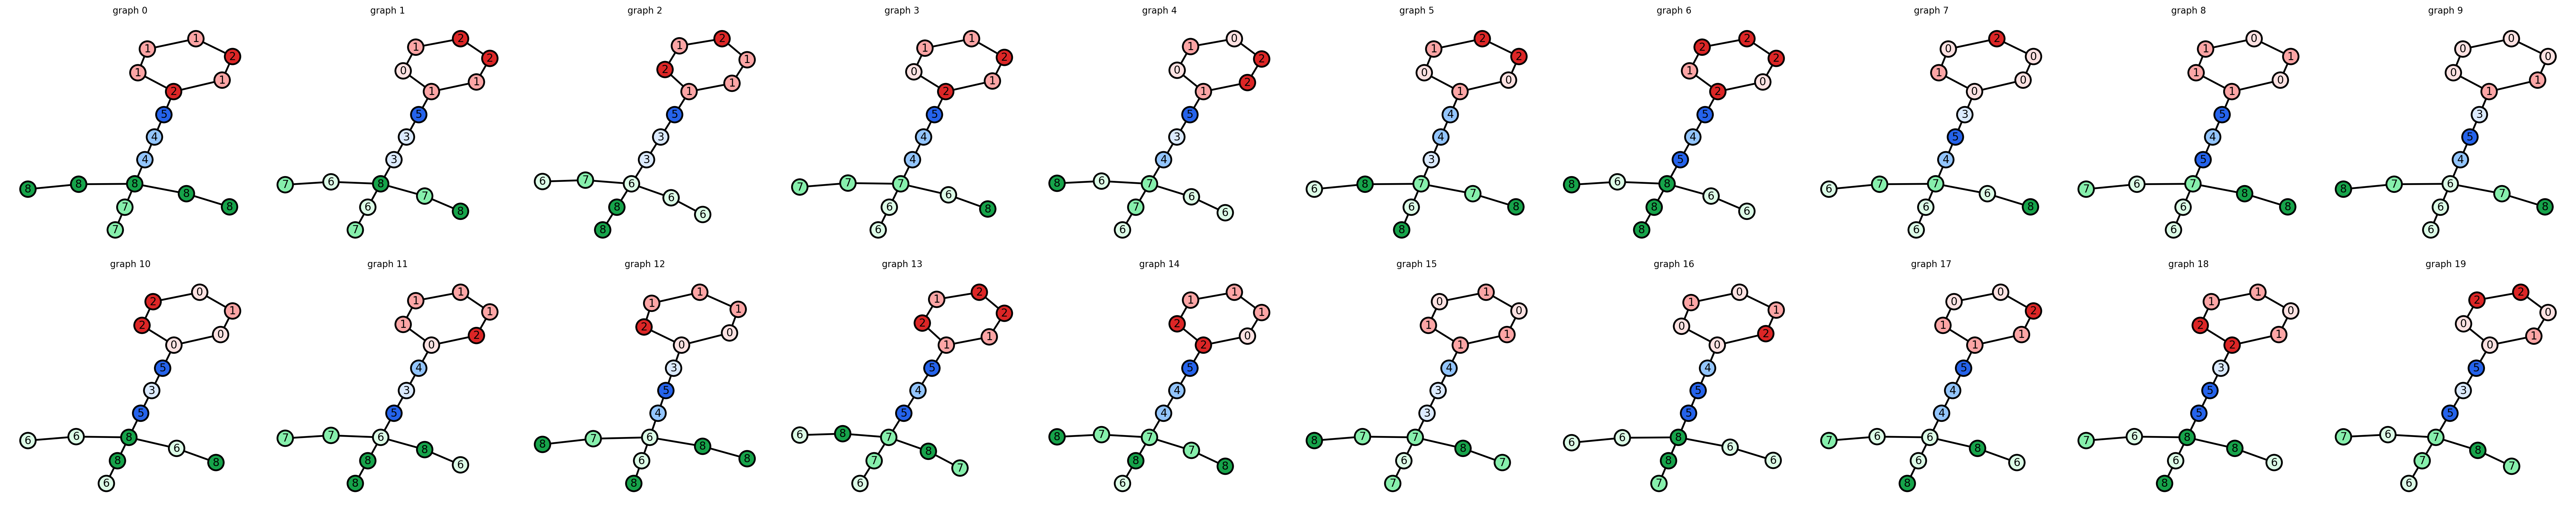

Configured graph generator model_name=artificial-cycle-path-star-n5000-c6-p4-r3x2-d64-b128-e350 model_dir=/run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/NodeField/.artifacts/saved_generators


In [3]:
graphs = generate_artificial_dataset(
    num_graphs=DATASET_SIZE,
    cycle_length=CYCLE_LENGTH,
    path_length=PATH_LENGTH,
    num_rays=NUM_RAYS,
    ray_length=RAY_LENGTH,
    node_alphabet_size=NODE_ALPHABET_SIZE,
    edge_alphabet_size=EDGE_ALPHABET_SIZE,
    node_alphabet_kind=NODE_ALPHABET_KIND,
    edge_alphabet_kind=EDGE_ALPHABET_KIND,
    component_specific_alphabets=COMPONENT_SPECIFIC_ALPHABETS,
    seed=RANDOM_SEED,
)

node_counts = np.array([graph.number_of_nodes() for graph in graphs])
edge_counts = np.array([graph.number_of_edges() for graph in graphs])
print(f'Loaded {len(graphs)} artificial graphs into memory for non-streaming fit.')
print(f'Node count min/median/max = {node_counts.min()}/{np.median(node_counts):.0f}/{node_counts.max()}')
print(f'Edge count min/median/max = {edge_counts.min()}/{np.median(edge_counts):.0f}/{edge_counts.max()}')
print('Metadata:', graphs[0].graph['metadata'])

plot_networkx_graphs(
    graphs[:20],
    n_cols=10,
    titles=[f'graph {idx}' for idx in range(20)],
    **ARTIFICIAL_GRAPH_PLOT_KWARGS,
)

graph_generator = build_graph_generator(
    latent_embedding_dimension=EMBEDDING_DIM,
    node_embedding_svd_dimension=EMBEDDING_DIM,
    number_of_transformer_layers=3,
    transformer_attention_head_count=4,
    locality_horizon=2,
    sparse_supervision_mask_ratio=0.9,
    maximum_epochs=MAXIMUM_EPOCHS,
    batch_size=FIT_BATCH_SIZE,
    verbose=2,
    decoder_n_jobs=DECODER_N_JOBS,
    artifact_root=ARTIFACT_ROOT,
    checkpoint_root=CHECKPOINT_ROOT,
    model_name=MODEL_NAME,
    model_dir=SAVED_GENERATOR_ROOT,
)
def render_artificial_graphs(decoded_graphs, **kwargs):
    graph_list = list(decoded_graphs)
    titles = kwargs.get('titles')
    plot_networkx_graphs(
        graph_list,
        n_cols=max(1, min(7, len(graph_list))),
        titles=titles,
        **ARTIFICIAL_GRAPH_PLOT_KWARGS,
    )


graph_generator.graph_decoder.diagnostic_graph_renderer = render_artificial_graphs


Fit target model_name=artificial-cycle-path-star-n5000-c6-p4-r3x2-d64-b128-e350 model_dir=/run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/NodeField/.artifacts/saved_generators
Fitting model on 5000 graphs
Fitted node embedding SVD: 2048 -> 64.
Fitted graph embedding SVD: 2048 -> 64.
Fitting feasibility estimator on 5000 graphs
Finished fitting feasibility estimator in 0m 59.6s
Supervision plan:
  node_labels: mode=learned, enabled. 9 node labels detected.
  edge_labels: mode=learned, enabled. 3 edge labels detected.
  direct_edges: mode=learned, enabled, horizon=1. Generator should learn horizon-1 edge presence for the decoder.
  auxiliary_locality: mode=learned, enabled, horizon=2. Use horizon-2 locality as auxiliary regularization.
adj_mtx_to_targets[direct_edge, horizon=1]: sampling 480000 pairs (50.00%) from 960000 total pairs (pos=320000, neg=640000, negative_sample_factor=1, sampling_strategy=stratified_preserve, target_positive_ratio=0.500).
adj_mtx_t

GPU available: False, used: False
TPU available: False, using: 0 TPU cores


epoch 1: starting validation


GPU available: False, used: False
TPU available: False, using: 0 TPU cores


epoch 1: finished validation in 2.22s
epoch 1: starting validation
epoch 1: finished validation in 11.30s
epoch 1: saving generator snapshot
epoch 1: finished generator snapshot in 0.37s
epoch 1: sampling training progress graphs
Sampling 3 raw graphs
Sampling 3 ILP graphs
epoch 1: appended training sample PDF page to /run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/NodeField/.artifacts/samples/artificial-cycle-path-star-n5000-c6-p4-r3x2-d64-b128-e350/training_samples.pdf
epoch 2: starting validation
epoch 2: finished validation in 11.52s
epoch 2: saving generator snapshot
epoch 2: finished generator snapshot in 0.35s
epoch 2: sampling training progress graphs
Sampling 3 raw graphs
Sampling 3 ILP graphs
epoch 2: appended training sample PDF page to /run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/NodeField/.artifacts/samples/artificial-cycle-path-star-n5000-c6-p4-r3x2-d64-b128-e350/training_samples.pdf
epoch 3: starting validation
e

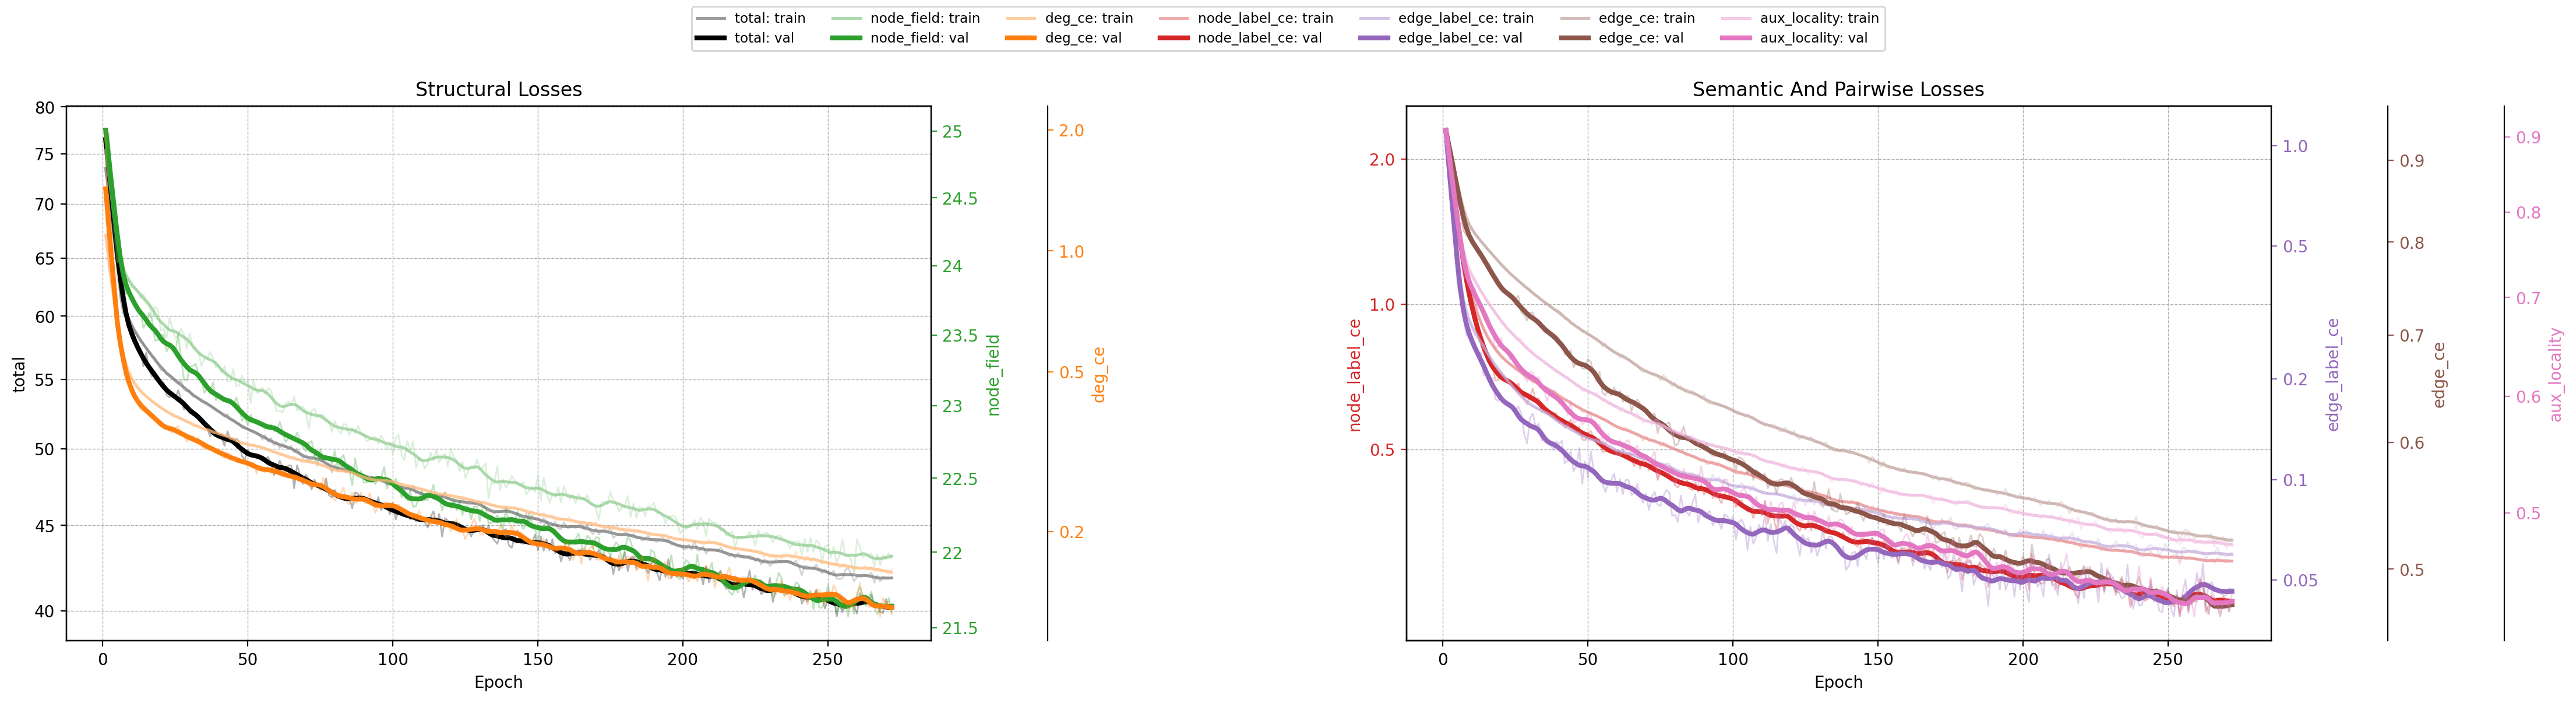

training_graph_conditioning_ = 5000
is_fitted_ = True
CPU times: user 27d 5h 37min 16s, sys: 4h 18min 39s, total: 27d 9h 55min 56s
Wall time: 2d 5h 16min 24s


In [10]:
%%time
graph_generator.fit(
    graphs,
    sample_training_progress=True,
    sample_training_progress_n_samples=3,
    sample_training_progress_every_n_epochs=1,
    sample_training_progress_plot_kwargs=ARTIFICIAL_GRAPH_PLOT_KWARGS,
)
print('training_graph_conditioning_ =', len(graph_generator.training_graph_conditioning_))
print('is_fitted_ =', graph_generator.is_fitted_)


In [4]:
# Optional reload path for a previously saved artificial non-streaming model.
from conditional_node_field_graph_generator.persistence import (
    list_saved_graph_generators,
    load_graph_generator,
)

list_saved_graph_generators(SAVED_GENERATOR_ROOT)
MODEL_FILENAME = f'{MODEL_NAME}.pkl'
graph_generator = load_graph_generator(MODEL_FILENAME, model_dir=SAVED_GENERATOR_ROOT)


,name,modified,size_mb
0,artificial-cycle-path-star-n5000-c6-p4-r3x2-d6...,2026-05-29 22:03,7.9
1,zinc15-nonstreaming-d64-s10000-b128-e350.pkl,2026-05-29 21:59,10.4


Loaded graph generator: artificial-cycle-path-star-n5000-c6-p4-r3x2-d64-b128-e350.pkl
/run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/NodeField/.artifacts/saved_generators/artificial-cycle-path-star-n5000-c6-p4-r3x2-d64-b128-e350.pkl


Sampling 7 raw graphs


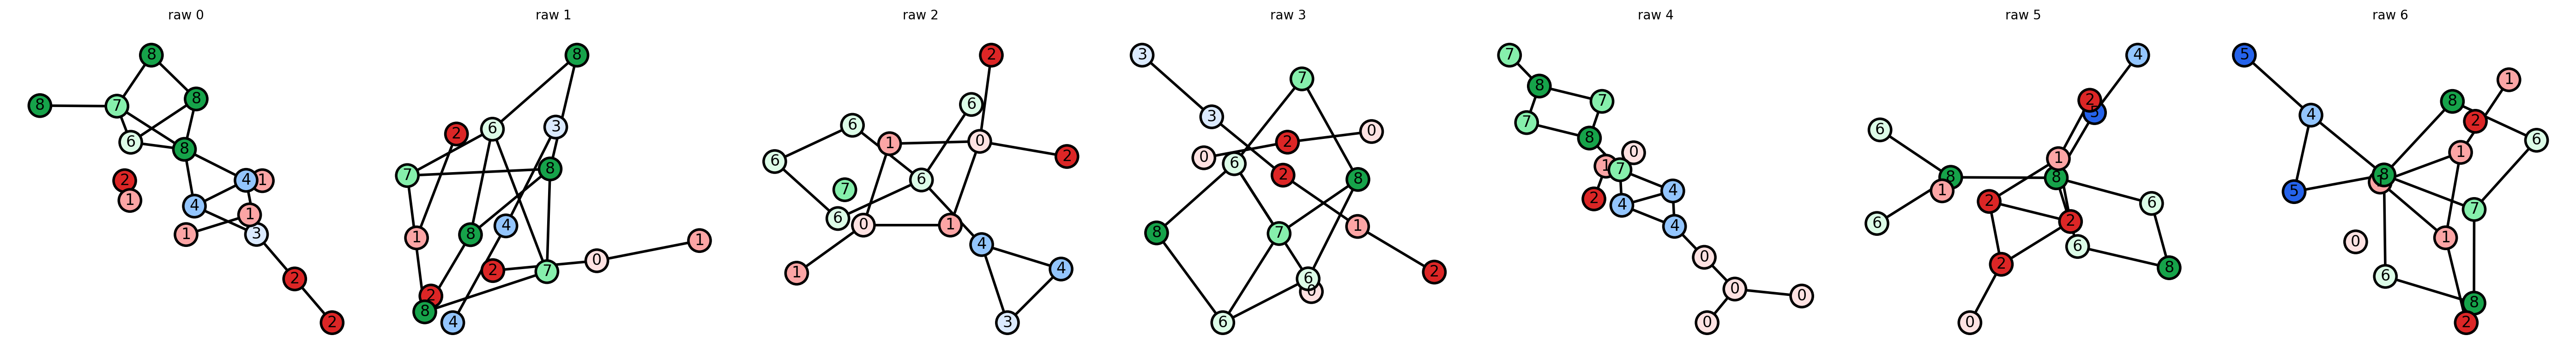

Sampling 7 ILP graphs


In [ ]:
n_samples = 7
raw_samples = graph_generator.sample(
    n_samples=n_samples,
    apply_feasibility_filtering=False,
    use_ilp_decoder=False,
)
plot_networkx_graphs(
    raw_samples,
    n_cols=n_samples,
    titles=[f'raw {idx}' for idx in range(len(raw_samples))],
    **ARTIFICIAL_GRAPH_PLOT_KWARGS,
)
#--------------------------------------------------------------------------------
ilp_samples = graph_generator.sample(
    n_samples=n_samples,
    apply_feasibility_filtering=False,
    use_ilp_decoder=True,
)
plot_networkx_graphs(
    ilp_samples,
    n_cols=n_samples,
    titles=[f'ilp {idx}' for idx in range(len(ilp_samples))],
    **ARTIFICIAL_GRAPH_PLOT_KWARGS,
)
#--------------------------------------------------------------------------------
oracle_ilp_samples = graph_generator.sample(
    n_samples=n_samples,
    apply_feasibility_filtering=False,
    use_ilp_decoder=True,
    use_feasibility_oracle=True,
)
plot_networkx_graphs(
    oracle_ilp_samples,
    n_cols=n_samples,
    titles=[f'oracle ilp {idx}' for idx in range(len(oracle_ilp_samples))],
    **ARTIFICIAL_GRAPH_PLOT_KWARGS,
)

Sampling 7 ILP graphs
Feasibility attempt  1/20 | generated=   8 | feasible_candidates= 1 | feasible_rate= 12.5% | attempt_time=2m 53.1s | eta=    0.0s
Feasibility filtering summary: generated=8, feasible_candidates=1, feasible_rate=12.5%, fulfilled_slots=1/1.
Feasibility attempt  1/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=3m 31.2s | eta=1h 06m 52.8s
Feasibility attempt  2/20 | generated=   8 | feasible_candidates= 2 | feasible_rate= 25.0% | attempt_time=2m 10.5s | eta=    0.0s
Feasibility filtering summary: generated=16, feasible_candidates=2, feasible_rate=12.5%, fulfilled_slots=1/1.
Feasibility attempt  1/20 | generated=   8 | feasible_candidates= 1 | feasible_rate= 12.5% | attempt_time=2m 26.7s | eta=    0.0s
Feasibility filtering summary: generated=8, feasible_candidates=1, feasible_rate=12.5%, fulfilled_slots=1/1.
Feasibility attempt  1/20 | generated=   8 | feasible_candidates= 5 | feasible_rate= 62.5% | attempt_time=1m 24.5s | eta=    0

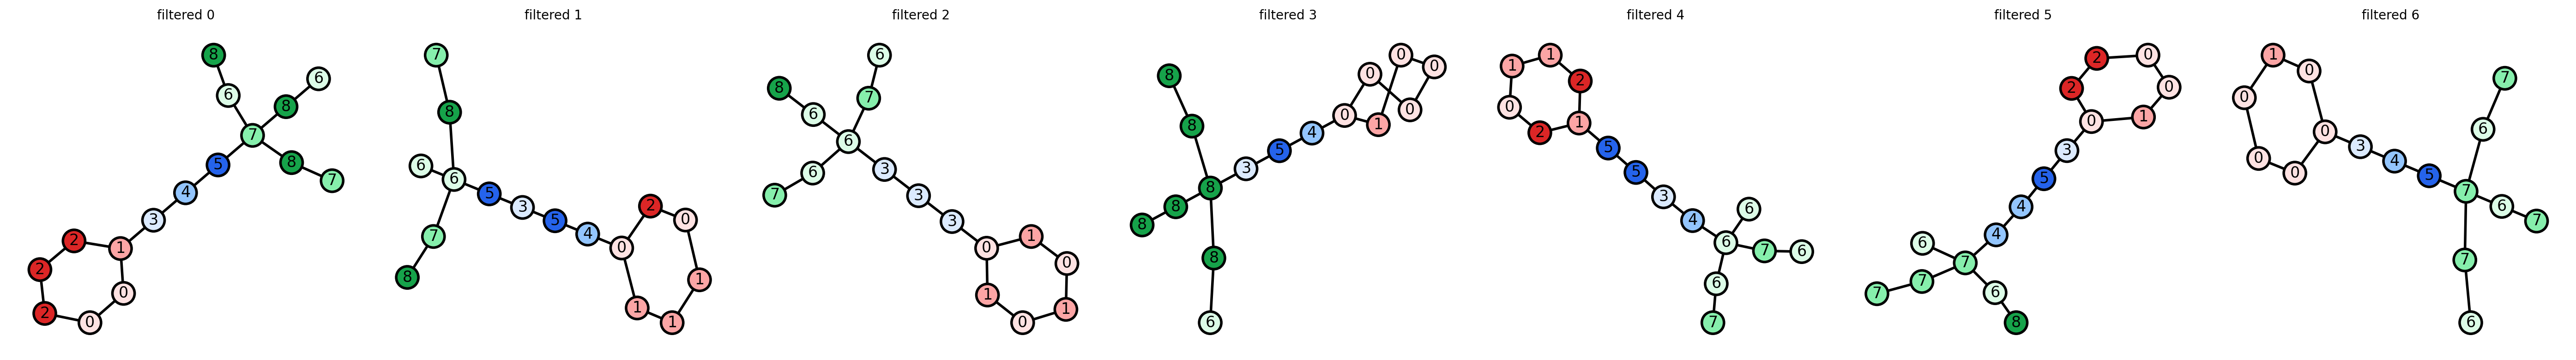

In [7]:
if graph_generator.feasibility_estimator is None:
    print('Feasibility estimator is unavailable in this environment; skipping filtered sampling.')
else:
    filtered_samples = graph_generator.sample(
        n_samples=n_samples,
        apply_feasibility_filtering=True,
    )
    plot_networkx_graphs(
        filtered_samples,
        n_cols=n_samples,
        titles=[f'filtered {idx}' for idx in range(len(filtered_samples))],
        **ARTIFICIAL_GRAPH_PLOT_KWARGS,
    )
